## Projection notebook

To predict recent elections we can't rely on data as there is a lag between the publication of socio-economic features and the election. We don't know the state of the society today. We need to project our features.

In [27]:
import sys
project_root = '/home/onyxia/work/election_modeling_uhcp/'
sys.path.insert(0, project_root)
from src.components.data_processing.data_loader import DataLoader 
import re
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import pandas as pd
from src.components.data_processing.projections_module import ProjectionModel, ProjectionUtils

In [28]:
dfc = DataLoader.load_dataset("s3://arthurmanceau/election_modeling_uhcp/data/derived/cache/dfc_cached.parquet")

2025-12-16 15:04:26.452 | DEBUG    | src.components.data_processing.data_loader:_read_parquet:55 - Loading dataset from s3://arthurmanceau/election_modeling_uhcp/data/derived/cache/dfc_cached.parquet...
2025-12-16 15:05:16.361 | DEBUG    | src.components.data_processing.data_loader:load_dataset:166 - Dataset loaded: (38145, 31557)


In [29]:
prefixes = dfc.columns.str.replace(r'\d{4}$', '', regex=True).unique()
features_list = prefixes.to_list()
features_list.remove('codecommune')
features_list.remove('dep')
print(features_list)

['agesexcommunes/poph014', 'agesexcommunes/poph1539', 'agesexcommunes/poph4059', 'agesexcommunes/poph60p', 'agesexcommunes/popf014', 'agesexcommunes/popf1539', 'agesexcommunes/popf4059', 'agesexcommunes/popf60p', 'agesexcommunes/ageh', 'agesexcommunes/agef', 'agesexcommunes/popf', 'agesexcommunes/poph', 'agesexcommunes/propf', 'agesexcommunes/age', 'agesexcommunes/pop', 'agesexcommunes/propf014', 'agesexcommunes/propf1539', 'agesexcommunes/propf4059', 'agesexcommunes/propf60p', 'agesexcommunes/prop014', 'agesexcommunes/prop1539', 'agesexcommunes/prop4059', 'agesexcommunes/prop60p', 'agesexcommunes/perpropf', 'agesexcommunes/perage', 'agesexcommunes/perprop014', 'agesexcommunes/perprop60p', 'agesexdepartements/popf', 'agesexdepartements/poph', 'agesexdepartements/popf60p', 'agesexdepartements/popf014', 'agesexdepartements/poph60p', 'agesexdepartements/poph014', 'agesexdepartements/poph1539', 'agesexdepartements/poph4059', 'agesexdepartements/popf1539', 'agesexdepartements/popf4059', 'ag

In [30]:
# def extract_year_from_column(x):
#     return re.search(r'\d{4}$', str(x))[0]

# def extract_feature_type_from_feature(x):
#     return re.sub(r'\d{4}$', '', str(x))

# def find_all_years_of(feature):
#     return [int(extract_year_from_column(c)) for c in dfc.columns if (feature in c and len(c.split('/')[1]) == len(feature.split('/')[1])+4)]

# def find_all_cols_of(feature):
#     return [c for c in dfc.columns if (feature in  c and len(c.split('/')[1]) == len(feature.split('/')[1])+4)]

# def find_last_year_of(feature):
#     return find_all_years_of(feature)[-1]

# def find_freq_of(feature):
#     l = np.sort(find_all_years_of(feature))
#     if len(l)<4:
#         return "N/A"
#     return int(np.mean([(l[i] - l[i-1]) for i in range(len(l)-4, len(l))]))

In [31]:
# class SimpleProjectionModel:

#     def __init__(self):
#         self.growth_rates = None
    
#     def fit(self, data):
#         self.growth_rates = data.pct_change(axis=1, fill_method=None).mean(skipna=True, axis=1)

#     def predict(self, s):
#         return (1+self.growth_rates) * s


In [32]:
# Create a list of columns to add
# reference_year = 2022
# target_proj = 2027-reference_year # 5 years
# not_projected_features = []
# projected_features = []
# new_columns = {}
# for feature in tqdm.tqdm(features_list):
#     y = find_last_year_of(feature)
#     f = find_freq_of(feature)
#     if (f!=1) or (y!=2022):
#         not_projected_features.append(feature)
#     else:
#         projected_features.append(feature)
#         base_columns = [f'{feature}{reference_year-i}' for i in range(0, 5)][::-1]
#         model = SimpleProjectionModel() # We fit one model for each feature speific to the time series
#         model.fit(data=dfc[base_columns])
#         for i in range(1, target_proj+1):
#             if i == 1:
#                 new_columns[f'{feature}{reference_year+i}'] = model.predict(dfc[f'{feature}{reference_year+(i-1)}'])
            # else:
            #     new_columns[f'{feature}{reference_year+i}'] = model.predict(new_columns[f'{feature}{reference_year+(i-1)}'])

In [33]:
# class ProjectionModel:

#     def __init__(self, p=5, alpha=None):
#         self.alpha = alpha
#         self.p = p
#         self.data = None
#         self.feature = None
#         self.reference_year = None
#         self.new_columns = {}

#     def fit(self, data):
#         self.data = data

#     def _find_col(self, i, feature, reference_year):
#         if i<=reference_year:
#             return self.data[f'{feature}{i}']
#         else:
#             col_name = f'{feature}{i}'
#             if col_name in self.new_columns:
#                 return self.new_columns[col_name]
#             else:
#                 raise Exception("Column not created yet.")

#     def predict_smoothing(self, start, end, feature, reference_year):
#         # Predict. Start from n and predict to k iteratively.
#         for i in range(start, end+1): # i = (n=2023), 2024, ..., (k=2027)
#             s = 0
#             for m in range(1, self.p+1):
#                 s+= self.alpha ** (m) * self._find_col(i-m, feature, reference_year) # i - m = (2022=2023-1=i-1), ... (2018=2022-5=i-p)

#             self.new_columns[f'{feature}{i}'] = self.alpha * self._find_col(i-1, feature, reference_year) + (1-self.alpha) * s
        
#         return self.new_columns

#     def predict_linear(self, start, end, feature, reference_year):
#         # Predict with a growth rate computed on the p previous years. From n to k.
#         for i in range(start, end+1):
#             data_series = [self._find_col(i-m, feature, reference_year) for m in range(1, self.p+1)][::-1] 
#             growth_rates = (pd.concat(data_series, axis=1)).pct_change(axis=1, fill_method=None).mean(skipna=True, axis=1)
#             self.new_columns[f'{feature}{i}'] = (1+growth_rates) * self._find_col(i-1)
#         return self.new_columns

In [34]:
# Create a list of columns to add
reference_year = 2022
target_proj = 2027-reference_year # 5 years
not_projected_features = []
projected_features = []
for feature in tqdm.tqdm(features_list):
    y = ProjectionUtils.find_last_year_of(feature, dfc)
    f =  ProjectionUtils.find_freq_of(feature, dfc)
    if (f!=1) or (y!=2022):
        not_projected_features.append(feature)
    else:
        projected_features.append(feature)

100%|██████████| 499/499 [00:04<00:00, 106.34it/s]


In [35]:
model = ProjectionModel(p=5, alpha=0.5)
model.fit(data=dfc)
new_columns = {}
for feature in projected_features:
    #new_columns_linear = {**new_columns, **model.predict_linear(start=2023, end=2027, feature=feature, reference_year=2022)}
    new_columns =  {**new_columns, **model.predict_smoothing(start=2023, end=2027, feature=feature, reference_year=2022)}

In [ ]:
df_new= pd.DataFrame(new_columns, index=dfc.index)
dfcp = pd.concat([dfc, df_new], axis=1)

In [38]:
# We can't project almost half of the features
len(projected_features), len(not_projected_features)

(170, 329)

## Validation 

In [39]:

def plot_feature_rows(dfc, feature_prefix, rows=None, n=5, agg='first', figsize=(10,6)):
    cols = [c for c in dfc.columns if c.startswith(feature_prefix)]
    if not cols:
        raise ValueError(f"No columns starting with {feature_prefix!r}")

    def col_key(c):
        m = re.search(r'(\d{4})$', c)
        return int(m.group(1)) if m else c
    cols = sorted(cols, key=col_key)

    if rows is None:
        rows = list(dfc.index[:n])
    elif isinstance(rows, int):
        rows = list(dfc.index[:rows])
    else:
        rows = list(rows)

    def normalize_cell(v):
        # handle pandas Series/DataFrame stored in a cell
        if isinstance(v, (pd.Series, pd.DataFrame)):
            arr = v.values.flatten()
            if arr.size == 0:
                return np.nan
            if arr.size == 1:
                return float(arr.item())
            return float(np.nanmean(arr))

        # handle numpy / list / tuple
        if isinstance(v, (list, tuple, np.ndarray)):
            arr = np.asarray(v)
            if arr.size == 0:
                return np.nan
            if arr.size == 1:
                return float(arr.item())
            return float(np.nanmean(arr))

        # now safe to use pandas missing check for scalars
        if pd.isna(v):
            return np.nan
        try:
            return float(v)
        except Exception:
            return np.nan

    xs = [col_key(c) for c in cols]
    if not all(isinstance(x, int) for x in xs):
        x_vals = list(range(len(cols)))
        xtick_labels = cols
    else:
        x_vals = xs
        xtick_labels = xs

    fig, ax = plt.subplots(figsize=figsize)
    for idx in rows:
        vals = []
        for c in cols:
            try:
                cell = dfc.at[idx, c] if idx in dfc.index else np.nan
            except Exception:
                cell = dfc.loc[idx, c] if (idx in dfc.index) else np.nan
            vals.append(normalize_cell(cell))
        ax.plot(x_vals, vals, '-o', label=str(idx))
    step = max(1, len(x_vals)//20)
    ax.set_xticks(x_vals[::step])
    ax.set_xticklabels([xtick_labels[i] for i in range(0, len(xtick_labels), step)], rotation=45, ha='right')
    ax.set_xlabel('column / year')
    ax.set_ylabel(feature_prefix)
    ax.legend(title='index', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    return fig, ax


In [43]:
projected_features

['agesexcommunes/poph014',
 'agesexcommunes/poph1539',
 'agesexcommunes/poph4059',
 'agesexcommunes/poph60p',
 'agesexcommunes/popf014',
 'agesexcommunes/popf1539',
 'agesexcommunes/popf4059',
 'agesexcommunes/popf60p',
 'agesexcommunes/ageh',
 'agesexcommunes/agef',
 'agesexcommunes/popf',
 'agesexcommunes/poph',
 'agesexcommunes/propf',
 'agesexcommunes/age',
 'agesexcommunes/pop',
 'agesexcommunes/propf014',
 'agesexcommunes/propf1539',
 'agesexcommunes/propf4059',
 'agesexcommunes/propf60p',
 'agesexcommunes/prop014',
 'agesexcommunes/prop1539',
 'agesexcommunes/prop4059',
 'agesexcommunes/prop60p',
 'agesexdepartements/popf',
 'agesexdepartements/poph',
 'agesexdepartements/ageh',
 'agesexdepartements/agef',
 'agesexdepartements/age',
 'agesexdepartements/pop',
 'agesexdepartements/propf',
 'agesexdepartements/propf014',
 'agesexdepartements/propf1539',
 'agesexdepartements/propf4059',
 'agesexdepartements/propf60p',
 'agesexdepartements/prop014',
 'agesexdepartements/prop1539',
 

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='column / year', ylabel='naticommunes/francais'>)

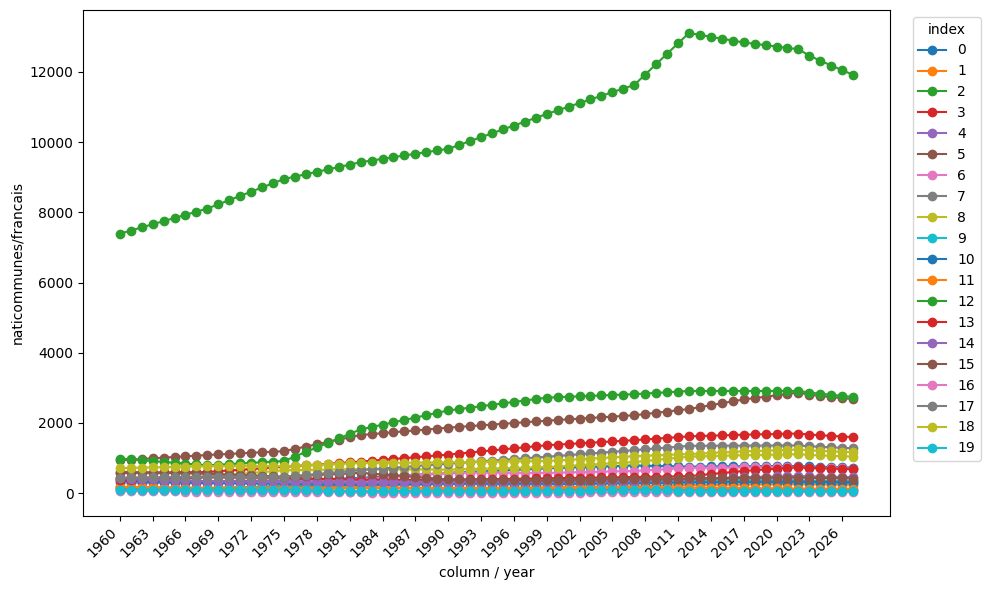

In [45]:
plot_feature_rows(dfcp, 'naticommunes/francais', n=20)